# Obfuscation Experiments 

In this file, we attempt to estimate the degree to which an executable file has been obfuscated. We compare the byte entropy, string entropy, opcode frequency, and metrics relating to the call graph of a given executable. 

In [2]:
import subprocess
from utils.data import MalwareDataset
from tqdm import tqdm
import concurrent.futures
import multiprocess
from typing import Callable, List, Tuple, Any
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import angr
import json
import string
from collections import Counter
import os
import networkx as nx
import r2pipe
import logging
import os

os.environ["R2_QUIET"] = "1"
logging.getLogger().setLevel("CRITICAL")
ERROR_SENTINAL = -100


def process_dataset(dataset: List[Tuple[str, int]], fn: Callable, num_workers: int = 4):
    malware, benign = [], []

    with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(fn, dataset), total=len(dataset)))

    for label, metric in results:
        if metric == ERROR_SENTINAL:
            continue

        if label == 1:
            malware.append(metric)
        else:
            benign.append(metric)

    return malware, benign


dataset = MalwareDataset()

# Opcode Frequency 

In [ ]:
base_path = "/Volumes/malware-dataset/opcodes/processed-data"

opcode_table = json.load(
    open(
        "/Users/henrywilliams/Documents/uni/masters-thesis/src/classifiers/static/opcode-transformer/vocab_table.json",
        "r",
    )
)


def make_counter():
    counter = {}
    for key in opcode_table:
        counter[key] = 0
    return Counter(counter)


def get_data(path: os.PathLike, full_path: bool = True) -> List[str]:
    all_files = os.listdir(path)

    if full_path:
        return [
            os.path.join(path, file)
            for file in all_files
            if file.endswith(".txt") and not file.startswith("._")
        ]
    else:
        return all_files


def get_labels(filenames):
    return [1 if "VirusShare" in filename else 0 for filename in filenames]


def analyse_frequency(path):
    table = make_counter()
    with open(path, "r") as f:
        lines = f.read().splitlines()

    total_instrs = len(lines)
    table.update(lines)

    if total_instrs <= 0:
        return table

    for instr, _ in table.items():
        table[instr] /= total_instrs

    return table


def handle_opcode_freq(x):
    return x[1], analyse_frequency(x[0])


paths = get_data(base_path)
labels = get_labels(get_data(base_path, False))
ds = [(path, label) for path, label in zip(paths, labels)]

mal_count, ben_count = process_dataset(ds, handle_opcode_freq, num_workers=8)

100%|██████████| 6940/6940 [01:27<00:00, 79.76it/s] 


In [ ]:
mal_freq = make_counter()
ben_freq = make_counter()
opcode_freq = make_counter()

for opcode in tqdm(mal_freq):
    mal_freq[opcode] = np.mean([cnt[opcode] for cnt in mal_count])
    ben_freq[opcode] = np.mean([cnt[opcode] for cnt in ben_count])
    opcode_freq[opcode] = (mal_freq[opcode] + ben_freq[opcode]) / 2

100%|██████████| 1293/1293 [00:03<00:00, 399.06it/s]


In [5]:
mal = np.array(list(mal_freq.values()))
ben = np.array(list(ben_freq.values()))
(mal @ ben) / (np.linalg.norm(mal) * np.linalg.norm(ben))

np.float64(0.9997187961695343)

# Entropy Analysis 

In [ ]:
def get_entropy(path: str):
    output = subprocess.run(
        ["rahash2", "-a entropy", path], capture_output=True
    ).stdout.decode("utf-8")
    parts = output.split(":")
    return float(parts[-1].strip())


def handle_entropy(x):
    try:
        return x[1], get_entropy(x[0])
    except:
        return x[1], ERROR_SENTINAL


malware_entropy, benign_entropy = process_dataset(
    dataset, handle_entropy, num_workers=8
)

100%|██████████| 11115/11115 [01:03<00:00, 174.11it/s]


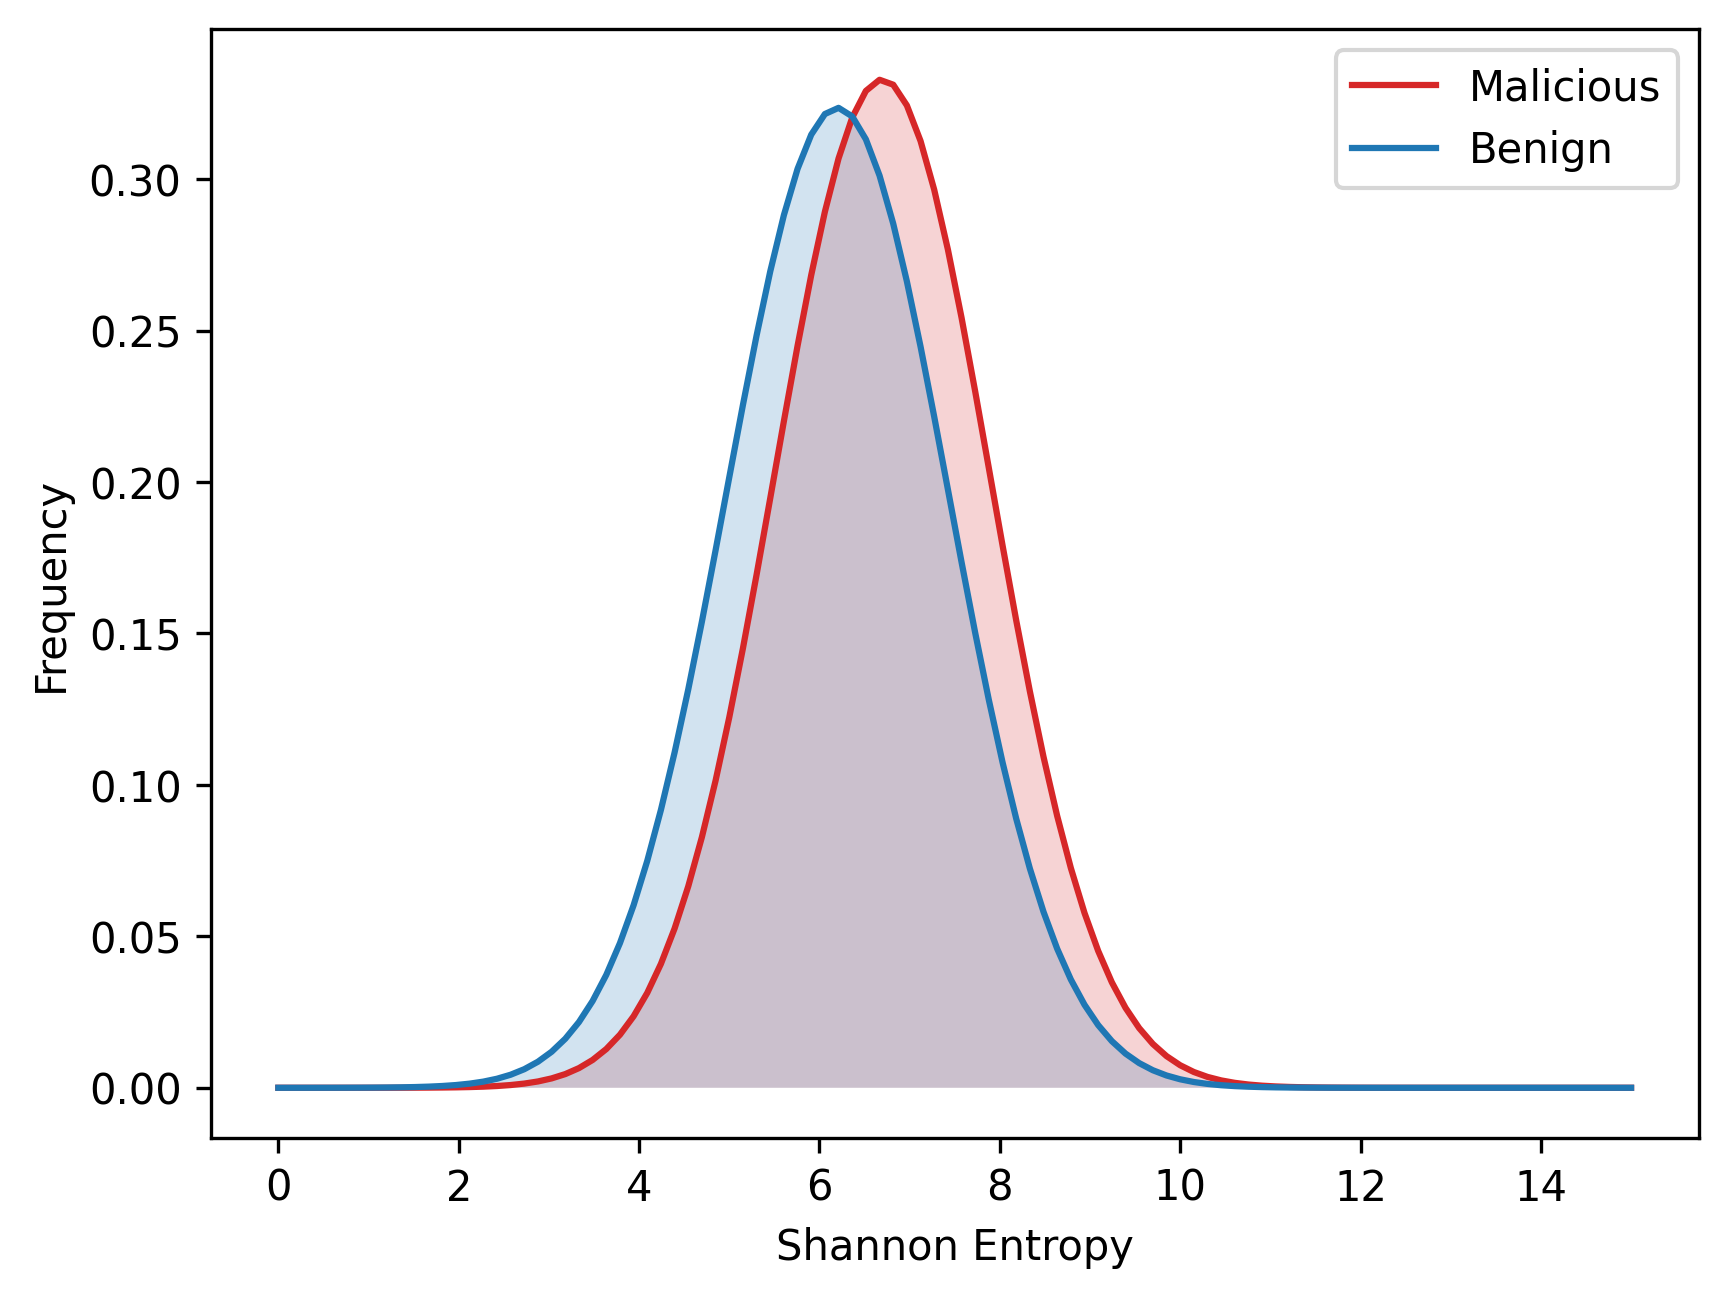

In [ ]:
x = np.linspace(0, 15, 100)
mu_m, std_m = np.mean(malware_entropy), np.std(malware_entropy)
mu_b, std_b = np.mean(benign_entropy), np.std(benign_entropy)

p_e_m = norm.pdf(x, mu_m, std_m)
p_e_b = norm.pdf(x, mu_b, std_b)
plt.figure(dpi=300)
plt.plot(x, p_e_m, label="Malicious", c="tab:red")
plt.fill_between(x, 0, p_e_m, alpha=0.2, facecolor="tab:red")
plt.plot(x, p_e_b, label="Benign", c="tab:blue")
plt.fill_between(x, 0, p_e_b, alpha=0.2)
plt.xlabel("Shannon Entropy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
P_B = (len(ds) - np.count_nonzero(labels)) / len(ds)
P_M = np.count_nonzero(labels) / len(ds)

pred = []
actual = []

for x, y in zip(malware_entropy + benign_entropy, labels):
    p_m = norm.pdf(x, mu_m, std_m)
    p_b = norm.pdf(x, mu_b, std_b)

    pred.append(
        np.argmax(
            [
                (p_b * P_B) / ((p_m * P_M) + (p_b * P_B)),
                (p_m * P_M) / ((p_m * P_M) + (p_b * P_B)),
            ]
        )
    )
    actual.append(y)

from sklearn.metrics import classification_report

print(classification_report(actual, pred))

precision    recall  f1-score   support

           0       0.57      0.42      0.49      3497
           1       0.54      0.68      0.60      3449

    accuracy                           0.55      6946
   macro avg       0.56      0.55      0.55      6946
weighted avg       0.56      0.55      0.54      6946

# String Entropy Analysis

In [ ]:
def get_string_entropy(path: str):
    out = subprocess.run(["strings", path], capture_output=True).stdout.decode("utf-8")
    data = "\n".join(out)
    freq = Counter(data)
    entropy = 0

    for c in string.printable:
        p_c = float(freq.get(c, 0) / len(data))

        if p_c > 0:
            entropy += -p_c * np.log2(p_c)

    return entropy


def handle_string_entropy(x):
    try:
        return x[1], get_string_entropy(x[0])
    except:
        return x[1], ERROR_SENTINAL


mal_str_entropy, ben_str_entropy = process_dataset(
    dataset, handle_string_entropy, num_workers=8
)

100%|██████████| 11115/11115 [04:09<00:00, 44.51it/s] 


(np.float64(3.6725633120476027), np.float64(3.5337748075467306))

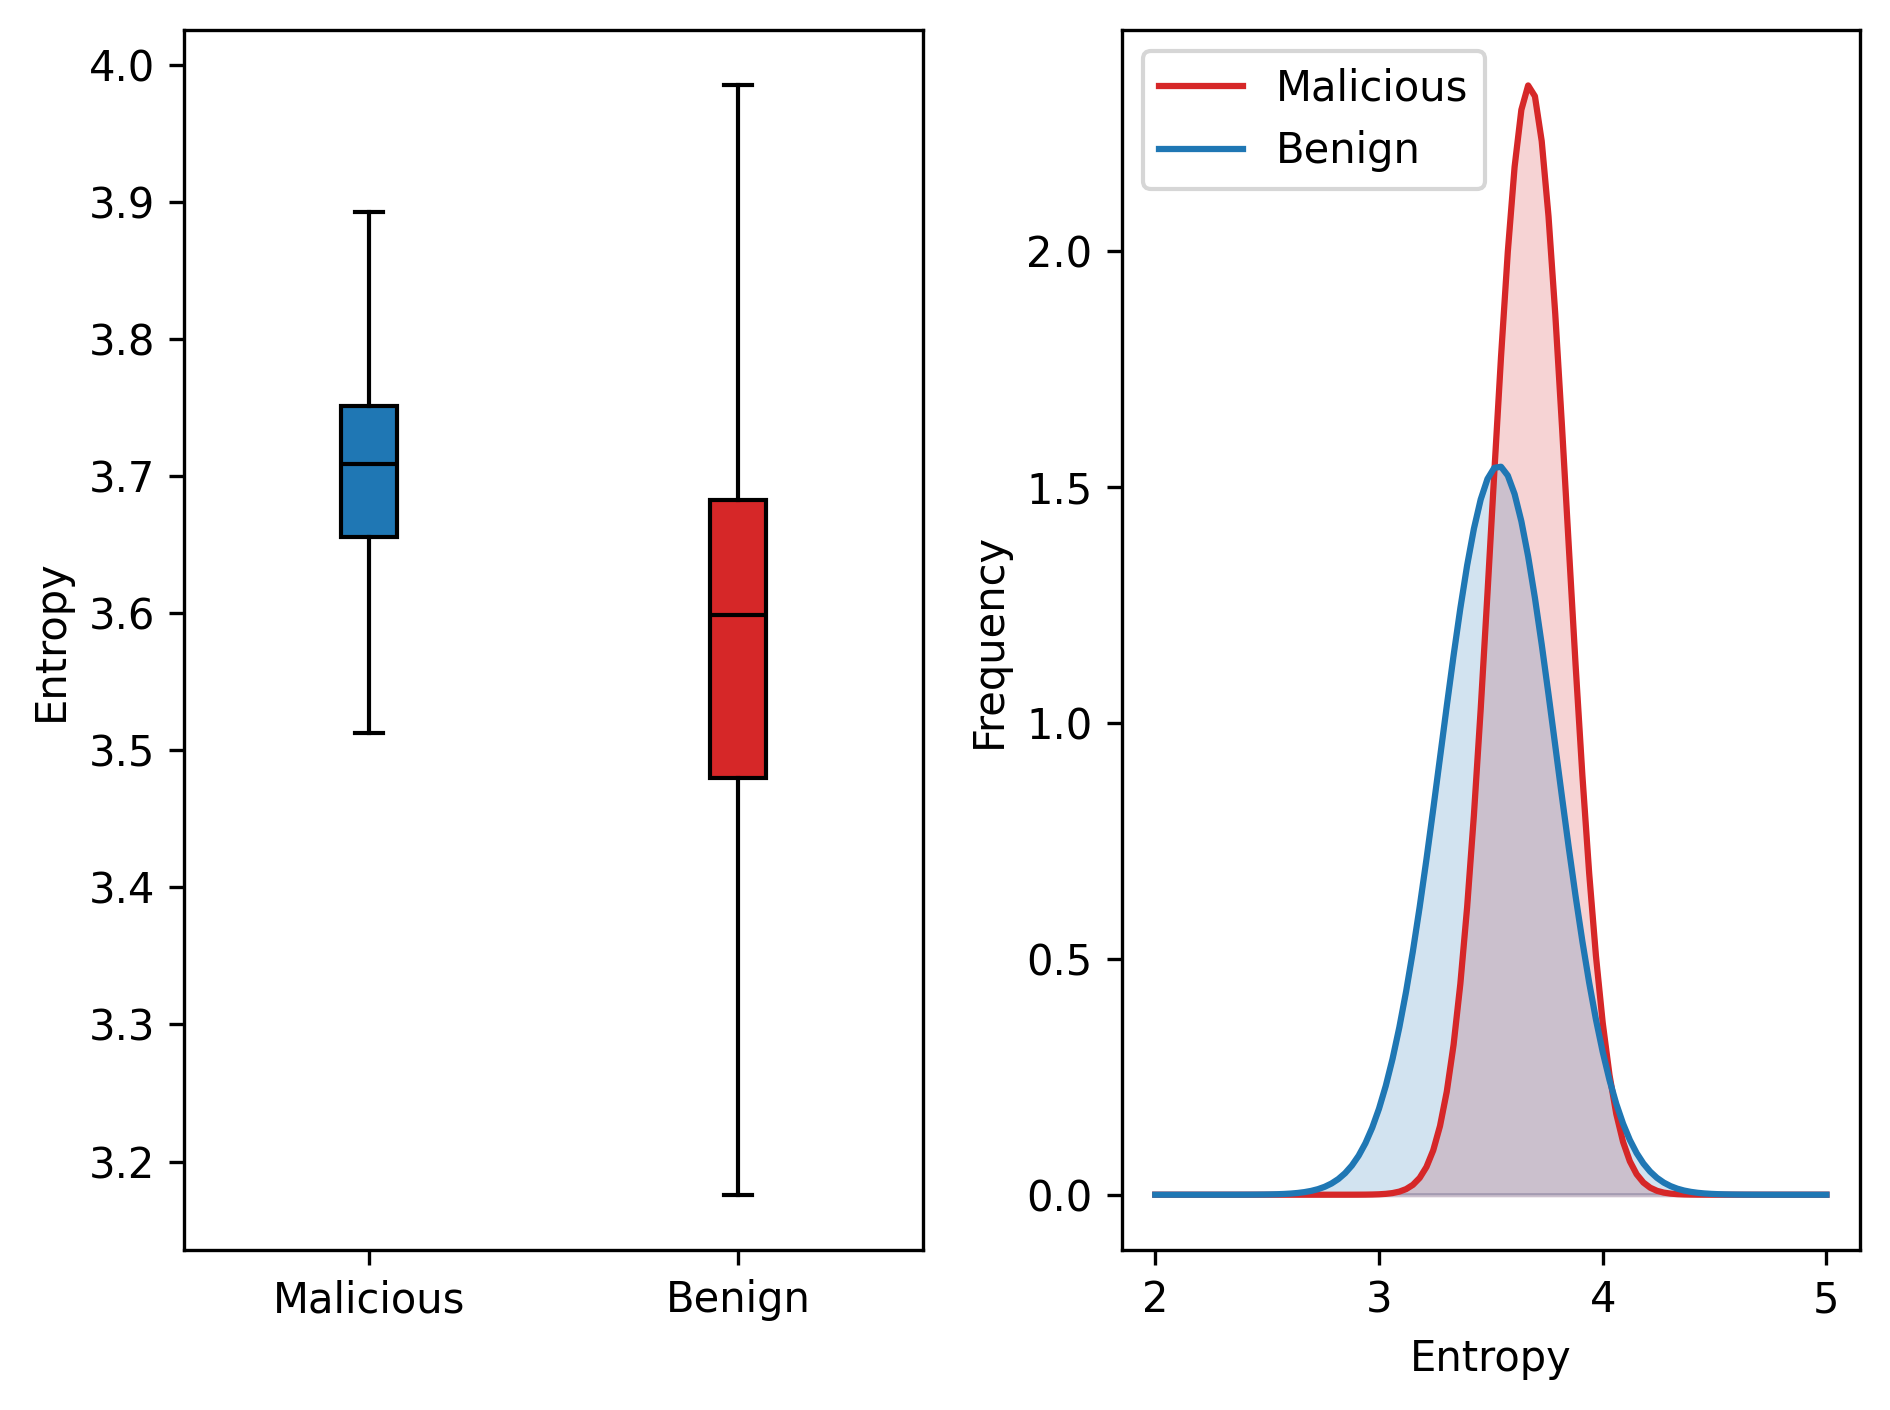

In [ ]:
fig, axs = plt.subplots(1, 2, dpi=300)
fig.set_tight_layout(True)

bp = axs[0].boxplot(
    [mal_str_entropy, ben_str_entropy],
    vert=True,
    patch_artist=True,
    tick_labels=["Malicious", "Benign"],
    medianprops={"color": "black"},
    sym="",
)

for box, color in zip(bp["boxes"], ["tab:blue", "tab:red"]):
    box.set(facecolor=color)

axs[0].set_ylabel("Entropy")

x = np.linspace(2, 5, 100)

mu_sm, std_sm = np.mean(mal_str_entropy), np.std(mal_str_entropy)
mu_sb, std_sb = np.mean(ben_str_entropy), np.std(ben_str_entropy)

p_e_m = norm.pdf(x, mu_sm, std_sm)
p_e_b = norm.pdf(x, mu_sb, std_sb)
axs[1].plot(x, p_e_m, label="Malicious", c="tab:red")
axs[1].fill_between(x, 0, p_e_m, alpha=0.2, color="tab:red")
axs[1].plot(x, p_e_b, label="Benign", c="tab:blue")
axs[1].fill_between(x, 0, p_e_b, alpha=0.2, color="tab:blue")
axs[1].set_xlabel("Entropy")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.show()


# TODO: Control Flow Graph 

In [ ]:
def get_cfg_metrics_worker(path: str, queue: multiprocess.Queue) -> None:
    # r2 = r2pipe.open(path, flags=["-q"])
    r2 = r2pipe.open(path, flags=["-2"])
    r2.cmd("aaa")  # Analyze the binary
    functions = json.loads(r2.cmd("aflj"))  # Get function metadata

    cfg = nx.DiGraph()

    for func in functions:
        fcn_addr = func["offset"]
        fcn_name = func["name"]

        cfg.add_node(fcn_addr, label=fcn_name)  # Add function node

        # Get basic blocks and edges
        blocks = json.loads(r2.cmd(f"agj @{fcn_addr}"))
        if not blocks:
            continue

        for block in blocks:
            for edge in block.get("edges", []):
                cfg.add_edge(block["addr"], edge["jump"])  # Add CFG edges

    r2.quit()
    queue.put(cfg)


def get_cfg_metrics(path: str, timeout: int = 60) -> Any:
    queue = multiprocess.Queue()
    process = multiprocess.Process(target=get_cfg_metrics_worker, args=(path, queue))

    process.start()
    process.join(timeout)

    if process.is_alive():
        process.terminate()
        process.join()
        return ERROR_SENTINAL

    return queue.get() if not queue.empty() else nx.DiGraph()


def handle_cfg(entry: Tuple[str, int]) -> Tuple[int, Tuple[int, int]]:
    path, label = entry
    return label, get_cfg_metrics(path)


m_cfgs = []
b_cfgs = []

for path, label in tqdm(dataset):
    if len(m_cfgs) >= 5:
        continue
    else:
        m_cfgs.append(get_cfg_metrics(path))

    if len(b_cfgs) >= 5:
        continue
    else:
        b_cfgs.append(get_cfg_metrics(path))

100%|██████████| 11115/11115 [02:05<00:00, 88.92it/s] 


# Rizin Analysis

In [5]:
from collections import defaultdict
import pandas as pd


def get_analysis(path):
    rz = subprocess.run(
        ["rizin", "-c", "aaij", "-q", path],
        capture_output=True,
        check=True,
    )
    return json.loads(rz.stdout.decode("utf-8"))


def run_analysis():
    rz_df = defaultdict(list)
    with open(
        "/Users/henrywilliams/Documents/programming/python/ai/malbert-test/notebooks/obfuscation-experiment-files.json",
        "r",
    ) as f:
        dataset = json.load(f)

    for path, label in tqdm(dataset.items()):
        try:
            analysis = get_analysis(path)
        except:
            continue

        rz_df["path"].append(path)
        rz_df["label"].append(label)

        for k, v in analysis.items():
            rz_df[k].append(v)

    return pd.DataFrame(rz_df)


if not os.path.exists("./rz_df_2.csv"):
    rz_df = run_analysis()
    rz_df.to_csv("./rz_df_2.csv")
else:
    rz_df = pd.read_csv("./rz_df_2.csv")

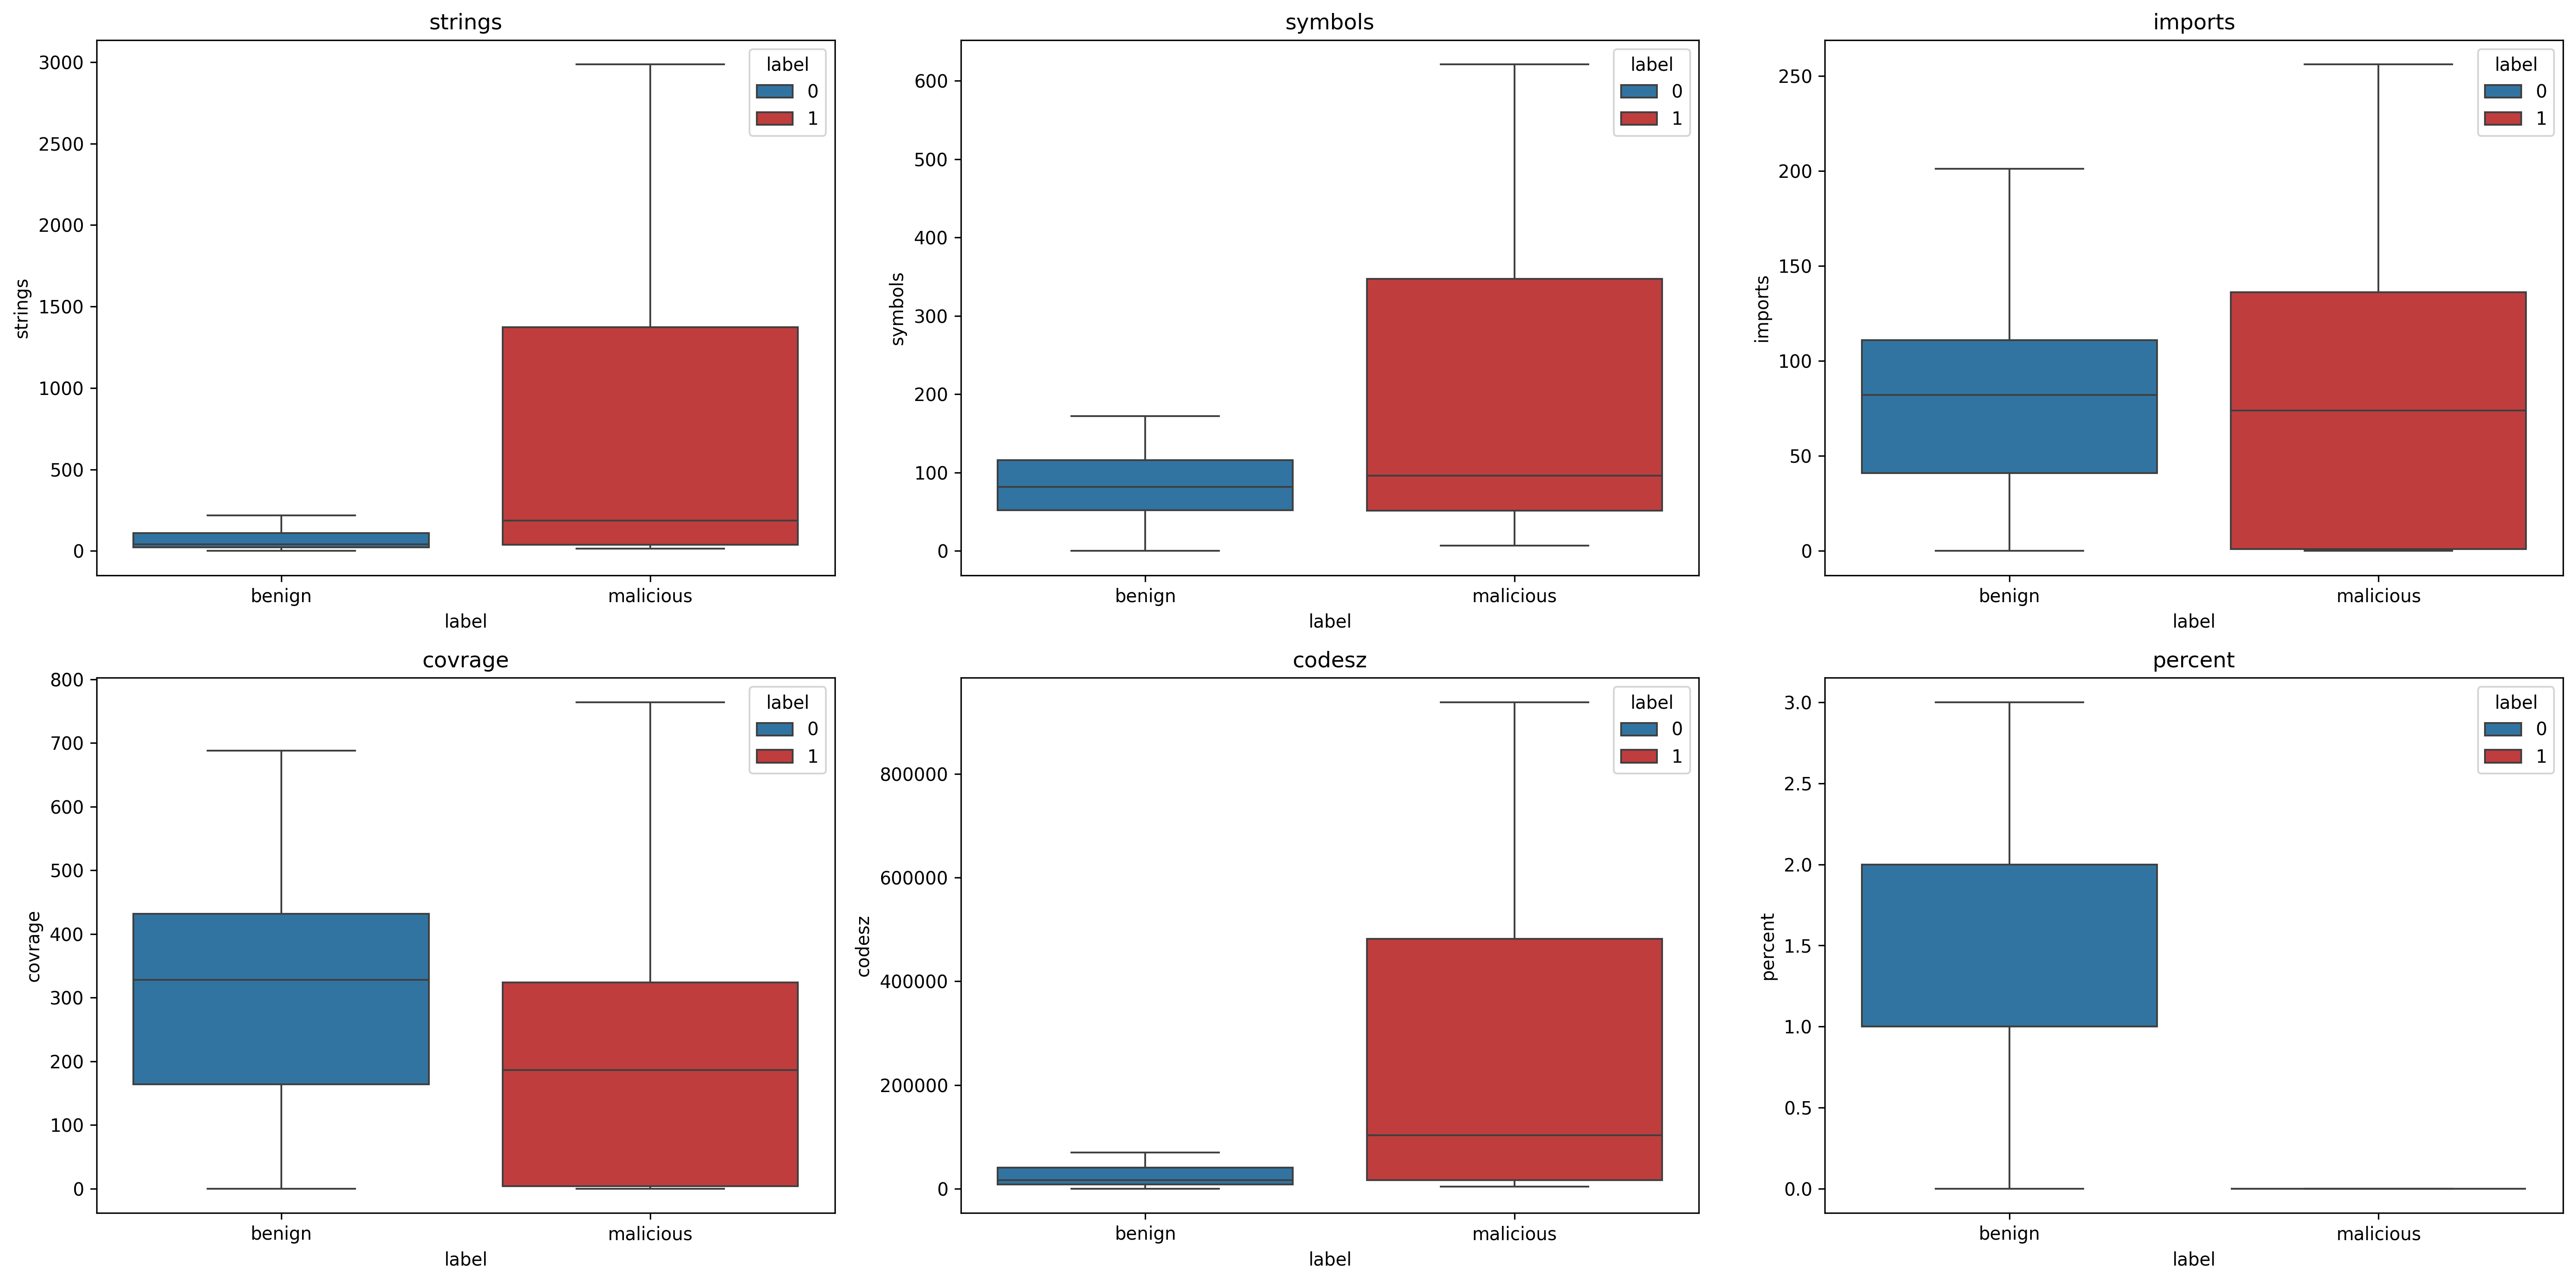

In [6]:
import seaborn as sns

keys = ["strings", "symbols", "imports", "covrage", "codesz", "percent"]

fig, axs = plt.subplots(2, 3, dpi=300, figsize=(20, 10))
fig.set_tight_layout(True)
for k, ax in zip(keys, axs.flatten()):
    sns.boxplot(
        data=rz_df,
        x="label",
        hue="label",
        palette={
            np.int64(0): "tab:blue",
            np.int64(1): "tab:red",
        },
        y=k,
        showfliers=False,
        formatter=lambda l: "benign" if l == 0 else "malicious",
        ax=ax,
    )
    ax.title.set_text(k)

plt.show()

In [8]:
foo = {
    "path": rz_df["path"],
    "label": rz_df["label"],
    "cov": rz_df["covrage"] / rz_df["codesz"],
}

foo = pd.DataFrame(foo)

Text(0.5, 0, 'Executable Kind')

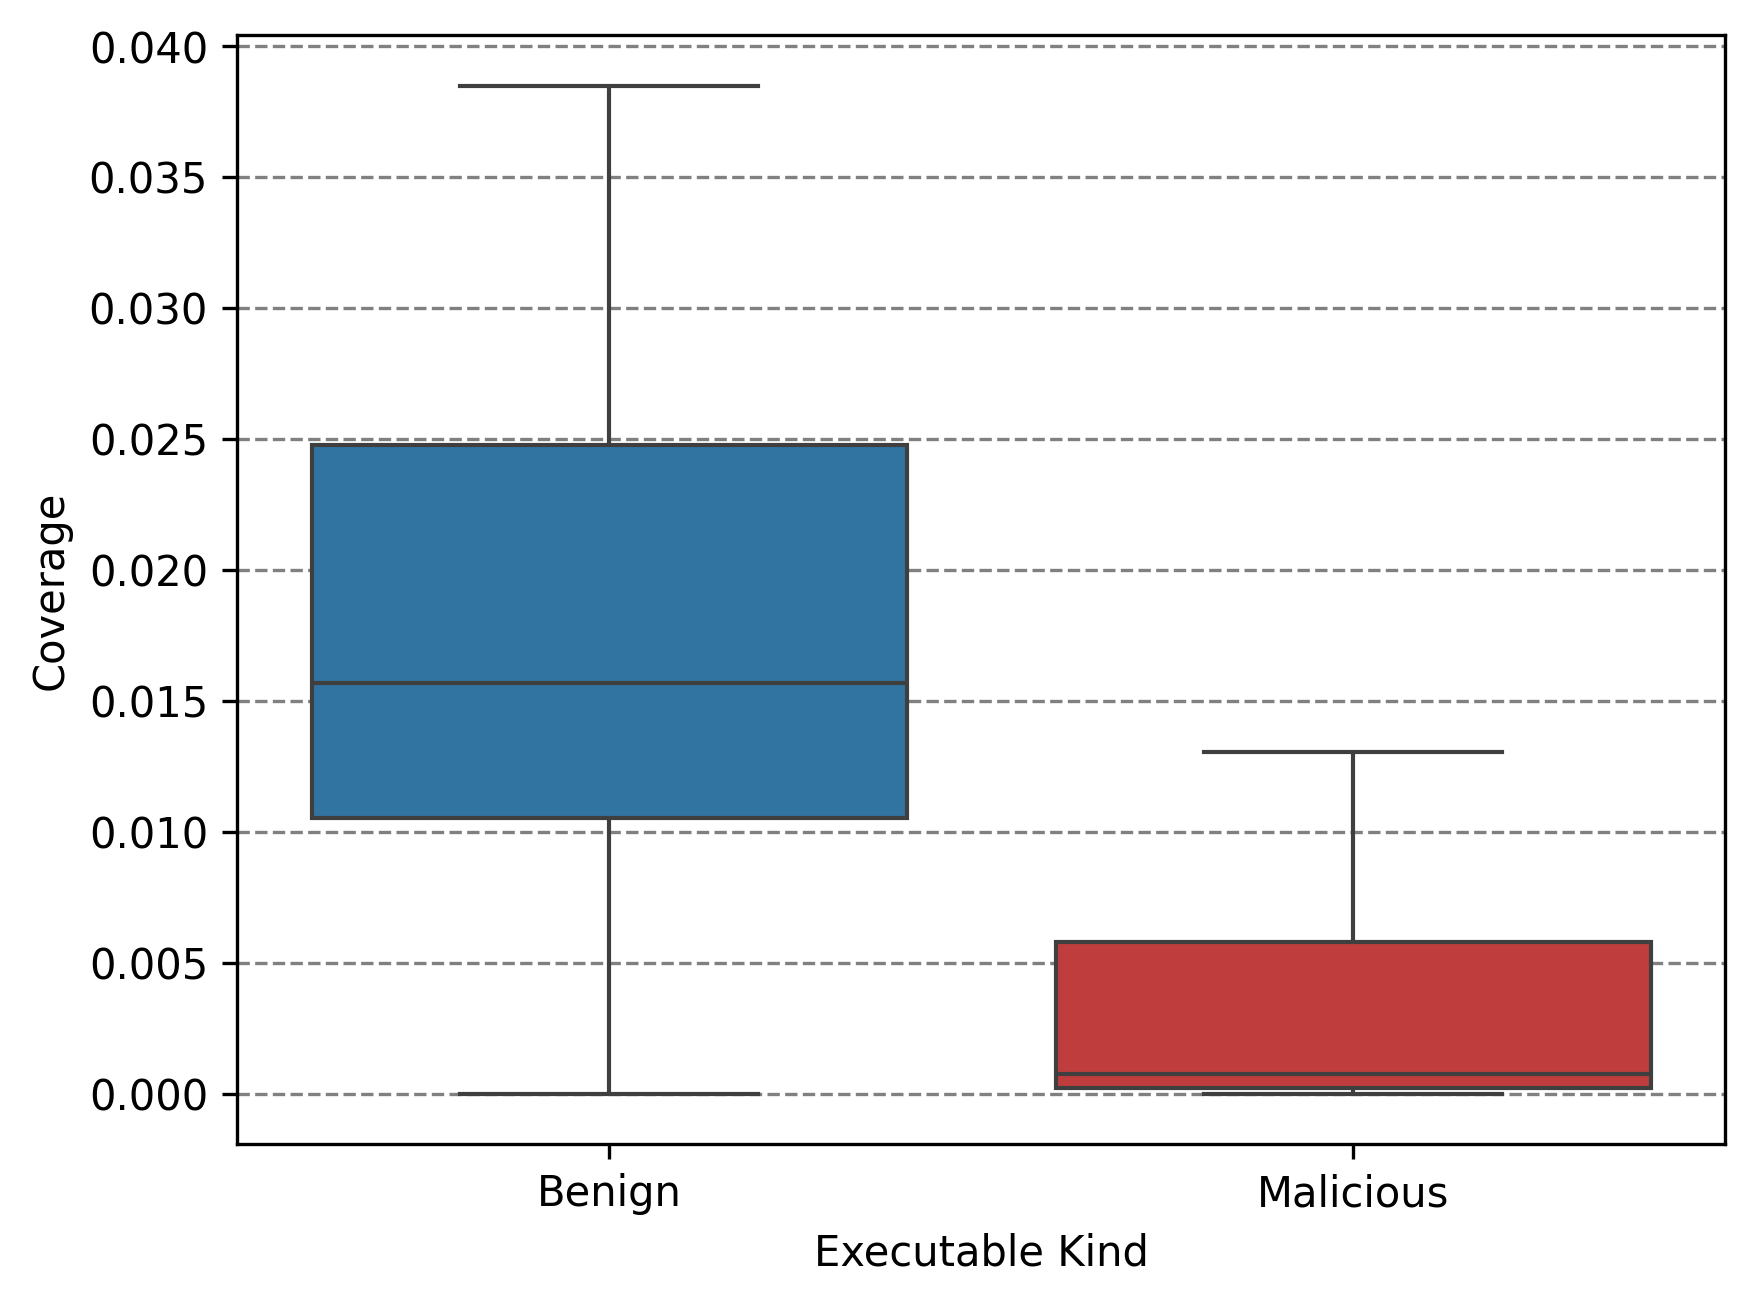

In [9]:
fig, ax = plt.subplots(dpi=300)

sns.boxplot(
    data=foo,
    x="label",
    hue="label",
    palette={
        np.int64(1): "tab:red",
        np.int64(0): "tab:blue",
    },
    y="cov",
    showfliers=False,
    formatter=lambda l: "Benign" if l == 0 else "Malicious",
    # log_scale=True,
    legend=False,
    ax=ax,
)
ax.grid(True, axis="y", linestyle="--", c="grey")
ax.set_ylabel("Coverage")
ax.set_xlabel("Executable Kind")

In [20]:
mean_b, std_b = (
    np.mean(foo[foo["label"] == 0]["cov"]),
    np.std(foo[foo["label"] == 0]["cov"]),
)
mean_m, std_m = (
    np.mean(foo[foo["label"] == 1]["cov"]),
    np.std(foo[foo["label"] == 1]["cov"]),
)

print(f"Malicious Executable Coverage: N({mean_m:.2}, {std_m:.2})")
print(f"Benign Executable Coverage: N({mean_b:.2}, {std_b:.2})")

Malicious Executable Coverage: N(0.0044, 0.0072)

Benign Executable Coverage: N(0.017, 0.01)

In [ ]:
def determine_dist(x):
    ll_m = np.log(norm.pdf(x, mean_m, std_m))
    ll_b = np.log(norm.pdf(x, mean_b, std_b))

    r = ll_m - ll_b

    if r > 0:
        return 1
    elif r < 0:
        return 0
    else:
        return None


actual = []
pred = []

ps = []
for row in foo.itertuples():
    y_hat = determine_dist(row.cov)

    if y_hat is None:
        continue

    ps.append(row.path)
    pred.append(y_hat)
    actual.append(row.label)

print(classification_report(actual, pred))

/var/folders/jd/lb_vbvw54zd00wp54hlkx4_m0000gn/T/ipykernel_44866/1577723451.py:3: RuntimeWarning: divide by zero encountered in log
  ll_b = np.log(norm.pdf(x, mean_b, std_b))


precision    recall  f1-score   support

           0       0.46      0.92      0.61      5319
           1       0.13      0.01      0.02      5792

    accuracy                           0.45     11111
   macro avg       0.30      0.47      0.32     11111
weighted avg       0.29      0.45      0.30     11111

In [77]:
correct = np.where(np.array(pred) == np.array(actual))
correct[0].shape

(4956,)